In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import plotly.express as px
from scipy import stats
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import PowerTransformer
from sklearn.mixture import GaussianMixture
from statsmodels.formula.api import ols
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
from additional import health_df, weather_df, extreme_df, CAUSES, df_wide, climate_features

In [3]:
clusters_plots_dir = Path("../results/clusters_plots")

### Data preparation

In [4]:
extreme_counts = extreme_df.groupby('country').agg({
    'is_extreme': 'sum',
    'year': 'nunique'
})
extreme_counts['extreme_freq'] = extreme_counts['is_extreme'] / extreme_counts['year']

for c in CAUSES:
    df_wide[f'log_{c}'] = np.log(df_wide[f"DALYs_{c}"].clip(lower=0.01))

log_targets = [f'log_{c}' for c in CAUSES]

country_profile = (
    df_wide.groupby('country')[climate_features + log_targets]
    .mean()
    .reset_index()
    .set_index('country')
)
country_profile = country_profile.join(extreme_counts[['extreme_freq']])
country_profile['seasonal_diff'] = country_profile['max_temp'] - country_profile['min_temp']
country_profile = country_profile.merge(
    df_wide[['country', 'income_level_mode']].drop_duplicates(subset='country'), 
    left_index=True, 
    right_on='country', 
    how='left'
).set_index('country')
print(f"Countries: {len(country_profile)}")
print(f"Climate features: {len(climate_features)}")

Countries: 40
Climate features: 43


# Clustering

## K-Means

### StandardScaler

In [ ]:
def run_clustering_pipeline(df, variants_config, scaler, model_class, **model_kwargs):
    ks = range(2, 9)
    cluster_labels = {}
    n_param = 'n_clusters' if 'KMeans' in str(model_class) else 'n_components'
    
    fig, axes = plt.subplots(1, len(variants_config), figsize=(6 * len(variants_config), 4))
    if len(variants_config) == 1: axes = [axes]

    for ax, (vname, features) in zip(axes, variants_config.items()):
        Xv = scaler.fit_transform(df[features]) if isinstance(features, list) else features
        
        sils, ines = [], []
        for k in ks:
            model = model_class(**{n_param: k}, random_state=42, **model_kwargs)
            if hasattr(model, 'fit_predict'):
                lbl = model.fit_predict(Xv)
            else:
                lbl = model.fit(Xv).predict(Xv)
            
            sils.append(silhouette_score(Xv, lbl))
            ines.append(model.inertia_ if hasattr(model, 'inertia_') else model.bic(Xv))

        best_k = list(ks)[np.argmax(sils)]
        max_sil = max(sils)
        print(f"\n{vname} (Best k={best_k}):")
        results_line = []
        for k, s in zip(ks, sils):
            marker = " ←" if k == best_k else ""
            results_line.append(f"  k={k}: sil={s:.3f}{marker}")
        print("".join(results_line))

        final_model = model_class(**{n_param: best_k}, random_state=42, **model_kwargs)
        labels = final_model.fit(Xv).predict(Xv) if not hasattr(final_model, 'fit_predict') else final_model.fit_predict(Xv)
        cluster_labels[vname] = labels
        
        counts = Counter(labels)
        dist_str = ", ".join([f"Cluster {cl}: {count}" for cl, count in sorted(counts.items())])
        print(f"Number of countries: {dist_str}")
        ax2 = ax.twinx()
        ax.plot(list(ks), ines, 'b-o', alpha=0.4)
        ax2.plot(list(ks), sils, 'r-s')
        ax.set_title(f'{vname}\nbest k={best_k} (sil={max_sil:.3f})')
        ax2.axvline(best_k, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()
    return cluster_labels


A: All climate + extremes (Best k=2):
  k=2: sil=0.364 ←  k=3: sil=0.355  k=4: sil=0.314  k=5: sil=0.296  k=6: sil=0.215  k=7: sil=0.217  k=8: sil=0.215
Number of countries: Cluster 0: 12, Cluster 1: 28

B: Health-relevant + extremes (Best k=2):
  k=2: sil=0.543 ←  k=3: sil=0.519  k=4: sil=0.508  k=5: sil=0.519  k=6: sil=0.483  k=7: sil=0.452  k=8: sil=0.450
Number of countries: Cluster 0: 27, Cluster 1: 13

C: PCA (85% variance) (Best k=3):
  k=2: sil=0.420  k=3: sil=0.427 ←  k=4: sil=0.395  k=5: sil=0.375  k=6: sil=0.295  k=7: sil=0.304  k=8: sil=0.303
Number of countries: Cluster 0: 17, Cluster 1: 12, Cluster 2: 11


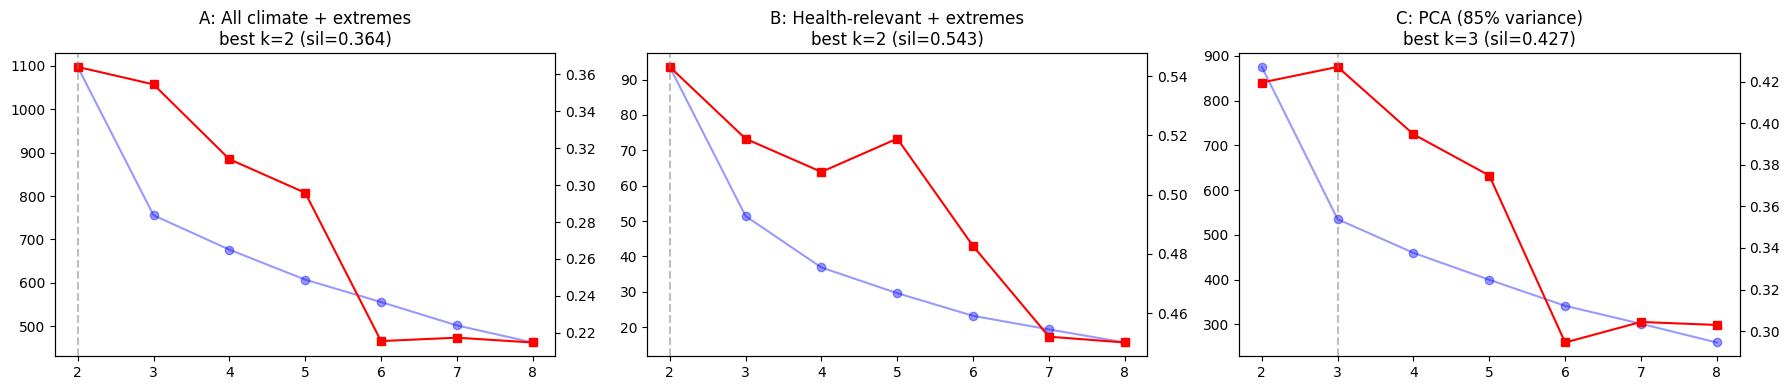

In [25]:
health_relevant = [
    'caurion_area', 'anomaly_dry_area', 'annual_freeze_burden',
    'extreme_heat_episodes', 'mean_annual_net',
    'mean_annual_rsn', 'pm2.5_mean', 'winter_mean_snow_density',
    'extreme_freq', 'seasonal_diff'
]
health_relevant = [v for v in health_relevant if v in country_profile.columns]

features_A = climate_features + ['extreme_freq', 'seasonal_diff']
features_B = [v for v in health_relevant if v in country_profile.columns]

X_pca_input = StandardScaler().fit_transform(country_profile[features_A])
X_pca_ready = PCA(n_components=0.85, random_state=42).fit_transform(X_pca_input)

variants= {
    'A: All climate + extremes': features_A,
    'B: Health-relevant + extremes': features_B,
    'C: PCA (85% variance)': X_pca_ready
}

labels_km_sc = run_clustering_pipeline(country_profile, variants, StandardScaler(), KMeans, n_init=50)

In [32]:
def plot_clustering_pca(df, X_data, labels, title, save_path=None):
    """
    Plots a scatter plot based on 2D PCA with country names.
    """
    if isinstance(X_data, list):
        X_vals = PowerTransformer().fit_transform(df[X_data])
    else:
        X_vals = X_data
    sil = silhouette_score(X_vals, labels)
    counts = Counter(labels)
    
    print(f"\n--- Analysis for: {title.splitlines()[0]} ---")
    print(f"Silhouette Score: {sil:.3f}")
    print("Countries per cluster:")
    for cl_id, count in sorted(counts.items()):
        print(f"  Cluster {cl_id}: {count} countries")

    pca_2d = PCA(n_components=2)
    coords = pca_2d.fit_transform(X_vals)
    var_ratio = pca_2d.explained_variance_ratio_

    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=labels, 
                    palette='Set2', s=150, edgecolor='black', alpha=0.9)
    for i, country in enumerate(df.index):
        plt.text(coords[i, 0] + 0.05, coords[i, 1] + 0.05, str(country), fontsize=9)

    plt.xlabel(f'PC1 ({var_ratio[0]:.1%})', fontsize=12, fontweight='bold')
    plt.ylabel(f'PC2 ({var_ratio[1]:.1%})', fontsize=12, fontweight='bold')
    plt.title(f"{title}\n(Sil={sil:.3f})", fontsize=14)
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', facecolor='white')
    plt.show()


--- Analysis for: Clustering by health-relevant features ---
Silhouette Score: 0.545
Countries per cluster:
  Cluster 0: 27 countries
  Cluster 1: 13 countries


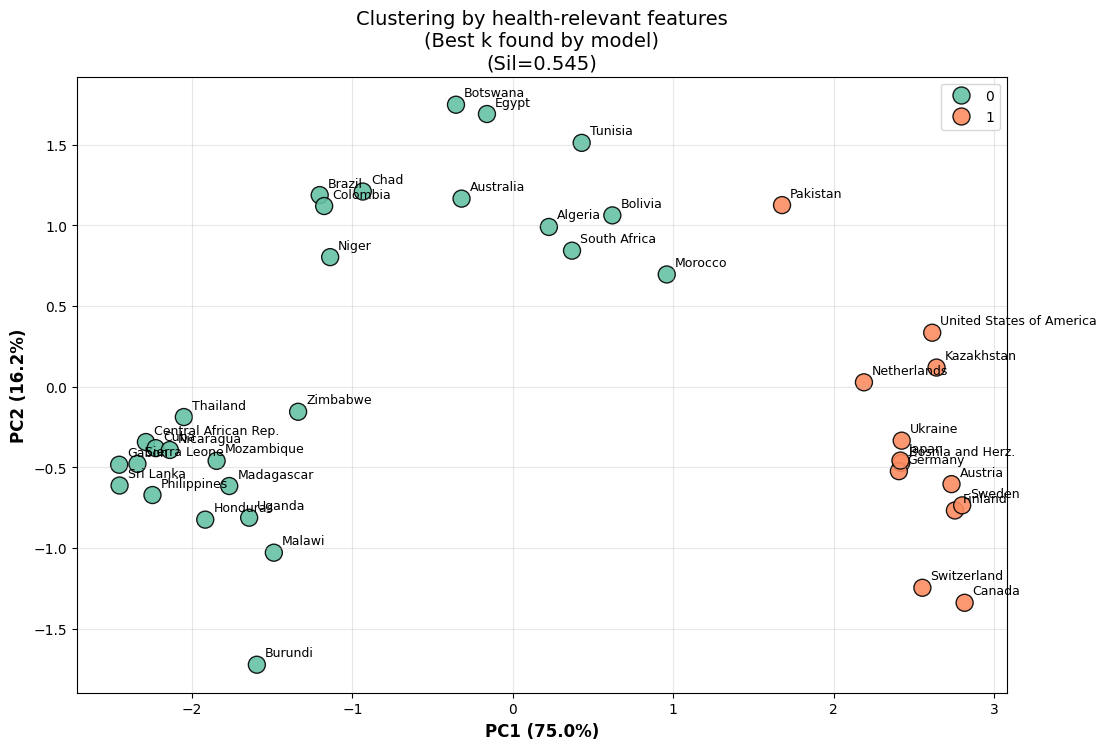

In [33]:
v_name_b = 'B: Health-relevant + extremes'
plot_clustering_pca(
    country_profile, 
    features_B, 
    labels_km_sc[v_name_b], 
    title=f"Clustering by health-relevant features\n(Best k found by model)",
)

### PowerTransformer

Let's try different scaler for KMeans


A: All climate + extremes (Best k=2):
  k=2: sil=0.360 ←  k=3: sil=0.356  k=4: sil=0.279  k=5: sil=0.250  k=6: sil=0.217  k=7: sil=0.202  k=8: sil=0.230
Number of countries: Cluster 0: 12, Cluster 1: 28

B: Health-relevant + extremes (Best k=3):
  k=2: sil=0.537  k=3: sil=0.564 ←  k=4: sil=0.514  k=5: sil=0.462  k=6: sil=0.433  k=7: sil=0.469  k=8: sil=0.464
Number of countries: Cluster 0: 15, Cluster 1: 13, Cluster 2: 12

C: PCA (85% variance) (Best k=3):
  k=2: sil=0.418  k=3: sil=0.432 ←  k=4: sil=0.361  k=5: sil=0.350  k=6: sil=0.325  k=7: sil=0.314  k=8: sil=0.325
Number of countries: Cluster 0: 12, Cluster 1: 17, Cluster 2: 11


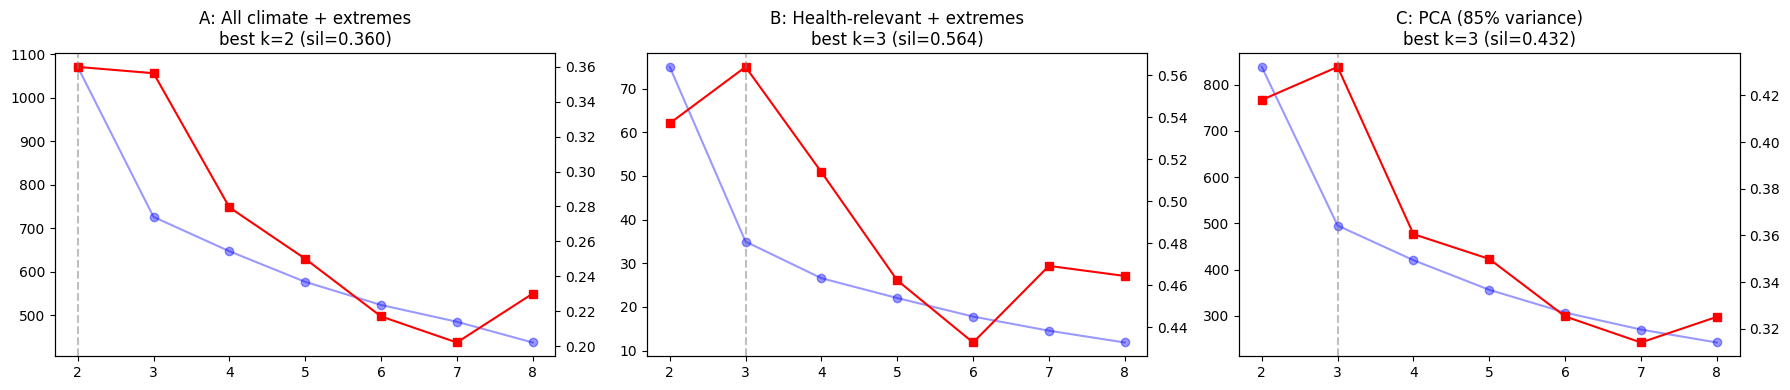

In [34]:
X_pca_input_pt = PowerTransformer().fit_transform(country_profile[features_A])
X_pca_pt_ready = PCA(n_components=0.85, random_state=42).fit_transform(X_pca_input_pt)

variants_pt = {
    'A: All climate + extremes': features_A,
    'B: Health-relevant + extremes': features_B,
    'C: PCA (85% variance)': X_pca_pt_ready
}

labels_km_pt = run_clustering_pipeline(country_profile, variants_pt, PowerTransformer(), KMeans, n_init=50)


--- Analysis for: Clustering by health-relevant features ---
Silhouette Score: 0.564
Countries per cluster:
  Cluster 0: 15 countries
  Cluster 1: 13 countries
  Cluster 2: 12 countries


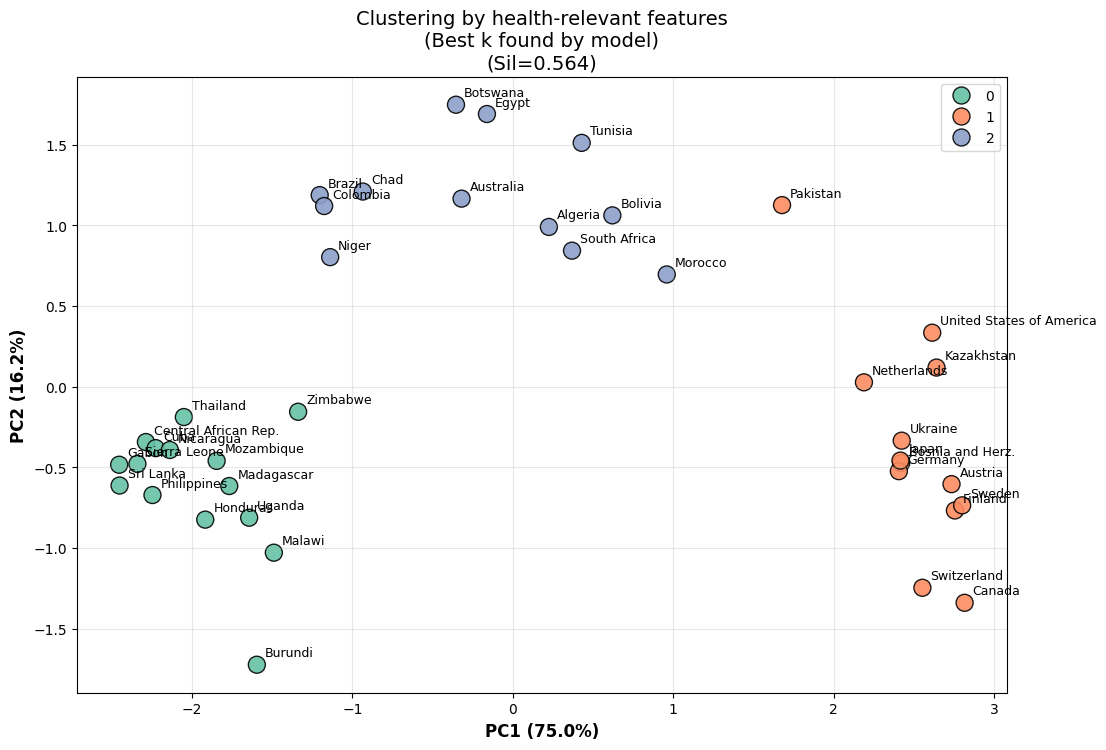


--- Analysis for: Clustering by PCA reduced features ---
Silhouette Score: 0.432
Countries per cluster:
  Cluster 0: 17 countries
  Cluster 1: 12 countries
  Cluster 2: 11 countries


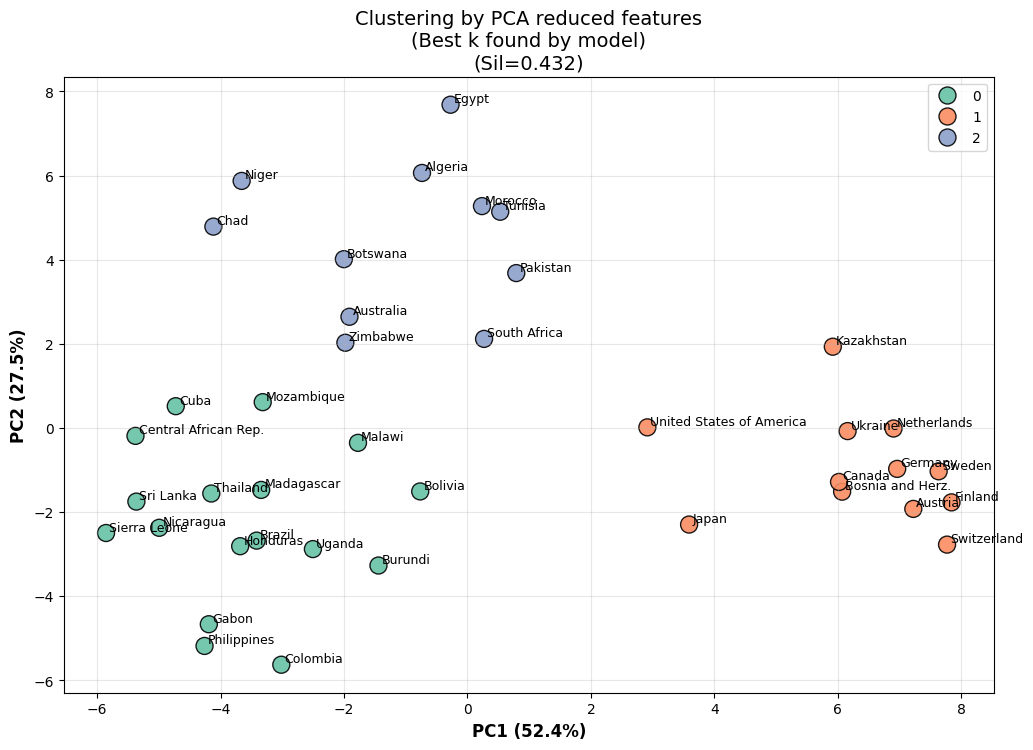

In [35]:
v_name_b = 'B: Health-relevant + extremes'
plot_clustering_pca(
    country_profile, 
    features_B, 
    labels_km_pt[v_name_b], 
    title=f"Clustering by health-relevant features\n(Best k found by model)",
    save_path=clusters_plots_dir / "k_means_health.pdf"
)

v_name_c = 'C: PCA (85% variance)'
plot_clustering_pca(
    country_profile, 
    X_pca_pt_ready,
    labels_km_sc[v_name_c], 
    title=f"Clustering by PCA reduced features\n(Best k found by model)",
)

country_profile['cluster_final'] = labels_km_pt[v_name_b]

The clusters are fairly distinct, but there are some outliers.

## GaussianMixture

Now I'll try using differnt clustering method.


A: All climate + extremes (Best k=3):
  k=2: sil=0.301  k=3: sil=0.356 ←  k=4: sil=0.271  k=5: sil=0.213  k=6: sil=0.227  k=7: sil=0.202  k=8: sil=0.133
Number of countries: Cluster 0: 11, Cluster 1: 12, Cluster 2: 17

B: Health-relevant + extremes (Best k=3):
  k=2: sil=0.522  k=3: sil=0.566 ←  k=4: sil=0.497  k=5: sil=0.460  k=6: sil=0.499  k=7: sil=0.462  k=8: sil=0.441
Number of countries: Cluster 0: 12, Cluster 1: 15, Cluster 2: 13

C: PCA (85% variance) (Best k=3):
  k=2: sil=0.418  k=3: sil=0.432 ←  k=4: sil=0.316  k=5: sil=0.318  k=6: sil=0.262  k=7: sil=0.226  k=8: sil=0.177
Number of countries: Cluster 0: 11, Cluster 1: 12, Cluster 2: 17


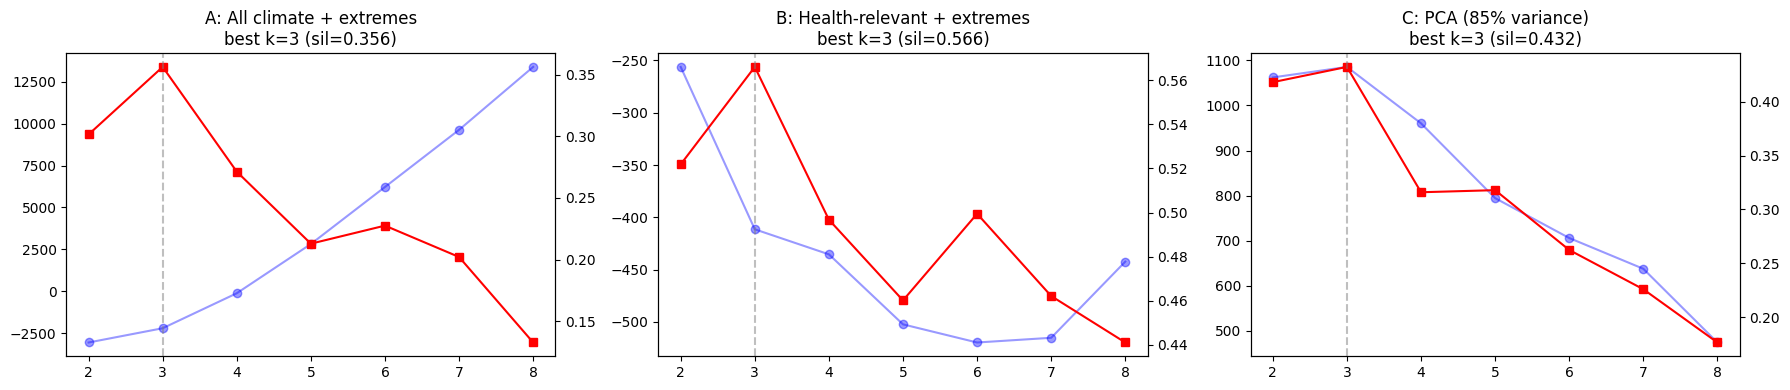

In [38]:
labels_gmm_pt = run_clustering_pipeline(country_profile, variants_pt, PowerTransformer(), GaussianMixture, n_init=50)

Clustering comparison: B: Health-relevant + extremes
Silhouette Score GMM:      0.566
Silhouette Score K-Means:  0.564
ARI (GMM vs K-Means):      0.929

GMM Distribution:
0    12
1    15
2    13
Name: count, dtype: int64

K-Means Distribution:
0    15
1    13
2    12
Name: count, dtype: int64


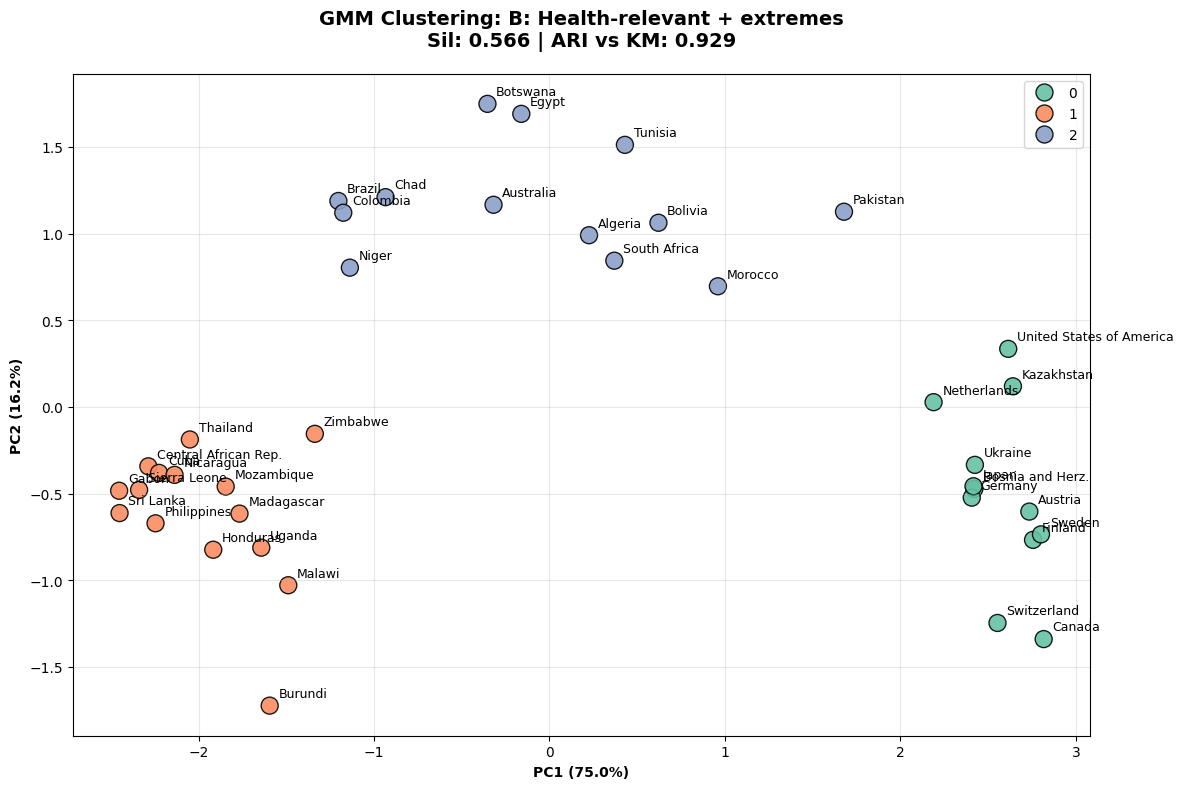

Clustering comparison: C: PCA (85% variance)
Silhouette Score GMM:      0.432
Silhouette Score K-Means:  0.432
ARI (GMM vs K-Means):      1.000

GMM Distribution:
0    11
1    12
2    17
Name: count, dtype: int64

K-Means Distribution:
0    12
1    17
2    11
Name: count, dtype: int64


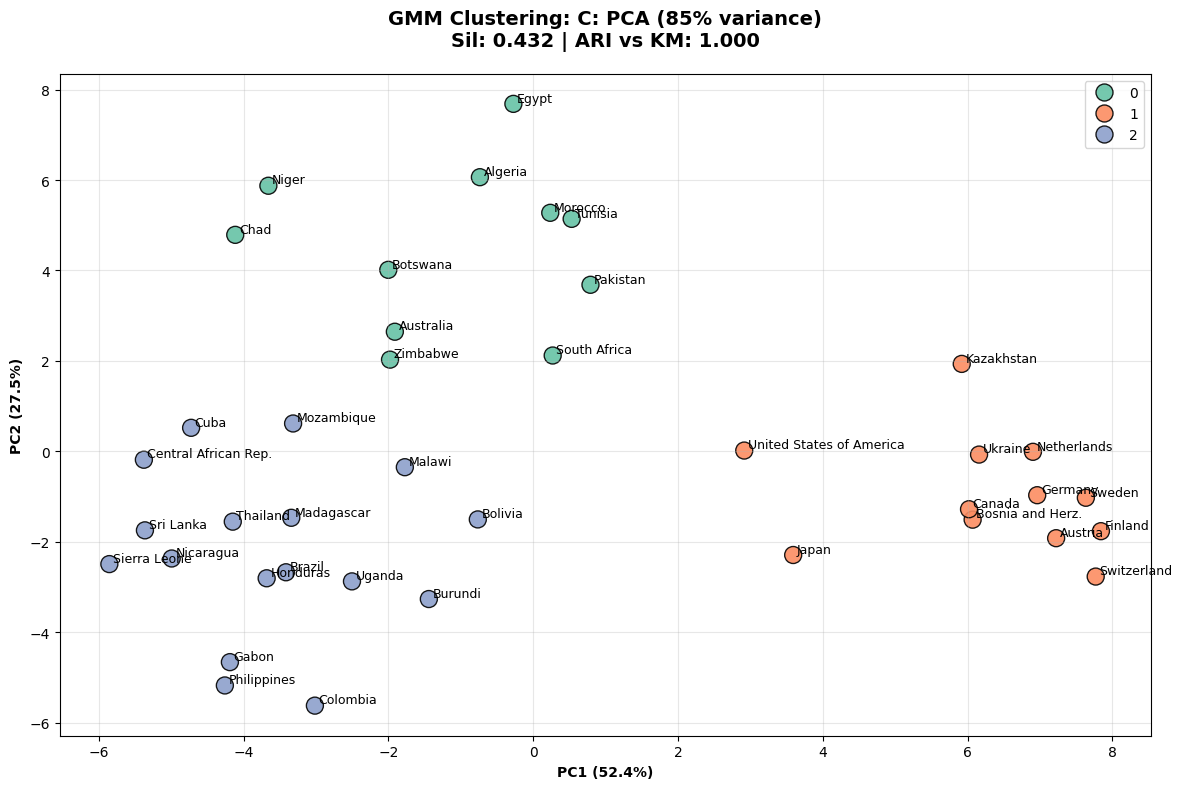

In [41]:
variants_to_compare = [
    ('B: Health-relevant + extremes', features_B, "gmm_health.pdf"),
    ('C: PCA (85% variance)', X_pca_pt_ready, "gmm_pca.pdf")
]

for vname, X_vals, filename in variants_to_compare:
    gmm_labels = labels_gmm_pt[vname]
    km_labels = labels_km_pt[vname]
    X_for_metrics = PowerTransformer().fit_transform(country_profile[X_vals]) if isinstance(X_vals, list) else X_vals

    ari = adjusted_rand_score(gmm_labels, km_labels)
    sil_gmm = silhouette_score(X_for_metrics, gmm_labels)
    sil_km = silhouette_score(X_for_metrics, km_labels)
    
    print(f"Clustering comparison: {vname}")
    print(f"Silhouette Score GMM:      {sil_gmm:.3f}")
    print(f"Silhouette Score K-Means:  {sil_km:.3f}")
    print(f"ARI (GMM vs K-Means):      {ari:.3f}")
    
    print(f"\nGMM Distribution:")
    print(pd.Series(gmm_labels).value_counts().sort_index())
    print(f"\nK-Means Distribution:")
    print(pd.Series(km_labels).value_counts().sort_index())

    pca_2d = PCA(n_components=2)
    coords = pca_2d.fit_transform(X_for_metrics)
    
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=gmm_labels, 
                    palette='Set2', s=150, edgecolor='black', alpha=0.9)

    for i, country in enumerate(country_profile.index):
        plt.text(coords[i, 0]+0.05, coords[i, 1]+0.05, country, fontsize=9)

    plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontweight='bold')
    plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontweight='bold')
    plt.title(f'GMM Clustering: {vname}\n'
              f'Sil: {sil_gmm:.3f} | ARI vs KM: {ari:.3f}', fontsize=14, fontweight='bold', pad=20)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(clusters_plots_dir / filename, bbox_inches='tight', facecolor='white')
    plt.show()

Let's check stability

In [44]:
ks = range(2, 7)
results = []
X_input = PowerTransformer().fit_transform(country_profile[features_B])

for k in ks:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=20)
    labels = gmm.fit_predict(X_input)
    
    sil = silhouette_score(X_input, labels)
    ch_score = calinski_harabasz_score(X_input, labels)
    bic = gmm.bic(X_input)
    stabilities = []
    for i in range(5):
        labels_check = GaussianMixture(n_components=k, random_state=i, n_init=10).fit_predict(X_input)
        stabilities.append(silhouette_score(X_input, labels_check))
    sil_std = np.std(stabilities)
    
    results.append({
        'k': k, 
        'Silhouette': sil, 
        'Silhouette_std': sil_std,
        'Calinski-Harabasz': ch_score, 
        'BIC': bic
    })
    
    print(f"k={k}: Sil={sil:.3f} (±{sil_std:.3f}) | CH={ch_score:6.1f} | BIC={bic:8.1f}")

metrics_df = pd.DataFrame(results)

k=2: Sil=0.522 (±0.000) | CH=  62.6 | BIC=  -256.2
k=3: Sil=0.566 (±0.000) | CH=  86.7 | BIC=  -411.4
k=4: Sil=0.497 (±0.008) | CH=  74.2 | BIC=  -435.4
k=5: Sil=0.518 (±0.014) | CH=  67.7 | BIC=  -483.9
k=6: Sil=0.499 (±0.018) | CH=  64.4 | BIC=  -519.6


The optimal number of clusters k=3, was selected as it excels across all evaluation metrics—highest Silhouette score (0.566 ±0.000), top Calinski-Harabasz index (CH=87), and good BIC (-411.4). This provides mathematical quality, perfect stability, and clear physical interpretability.


**Validation of the climate-health clustering.**
After GMM clustering (K=3), we: 
1) show the composition of the clusters (which countries),
2) visualize the distribution of DALYs 
(boxplot+stripplot),
3) perform an ANOVA to test whether the incidence rates differ **statistically 
significantly** across climate types. 

**Objective**: to demonstrate that climate clusters are relevant to health.

# Exploring clusters

Countries in clusters
------------------------------------------------------------

CLUSTER 0 (12 countries):
Austria, Bosnia and Herz., Canada, Finland, Germany, Japan, Kazakhstan, Netherlands, Sweden, Switzerland, Ukraine, United States of America

CLUSTER 1 (15 countries):
Burundi, Central African Rep., Cuba, Gabon, Honduras, Madagascar, Malawi, Mozambique, Nicaragua, Philippines, Sierra Leone, Sri Lanka, Thailand, Uganda, Zimbabwe

CLUSTER 2 (13 countries):
Algeria, Australia, Bolivia, Botswana, Brazil, Chad, Colombia, Egypt, Morocco, Niger, Pakistan, South Africa, Tunisia


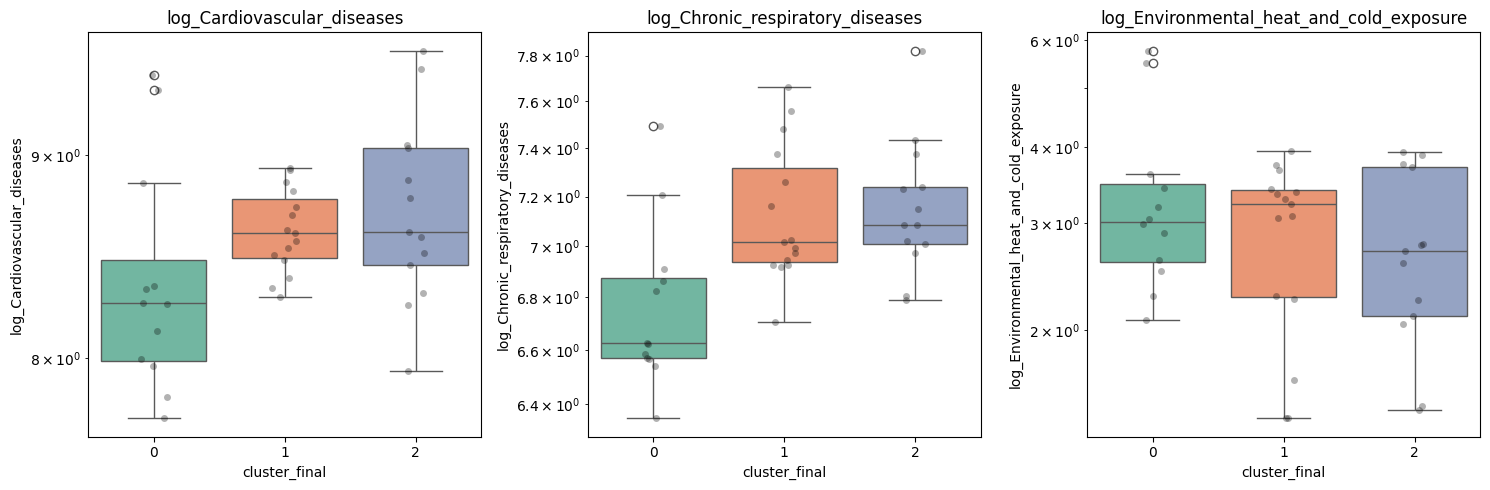


Kruskal-Wallis
------------------------------------------------------------
log_Cardiovascular_diseases                   | p-value: 0.0594
log_Chronic_respiratory_diseases              | p-value: 0.0028
log_Environmental_heat_and_cold_exposure      | p-value: 0.6391

Mann-Whitney
------------------------------------------------------------

log_Cardiovascular_diseases
  Cluster 0 vs 1: p=0.0299
  Cluster 0 vs 2: p=0.0606
  Cluster 1 vs 2: p=0.6450

log_Chronic_respiratory_diseases
  Cluster 0 vs 1: p=0.0019
  Cluster 0 vs 2: p=0.0051
  Cluster 1 vs 2: p=0.6784

log_Environmental_heat_and_cold_exposure
  Cluster 0 vs 1: p=0.9029
  Cluster 0 vs 2: p=0.2648
  Cluster 1 vs 2: p=0.6784


In [53]:
print("Countries in clusters")
print("-"*60)

gmm = GaussianMixture(n_components=3, random_state=42, n_init=50)
country_profile['cluster_final'] = gmm.fit_predict(X_input)

for c in sorted(country_profile['cluster_final'].unique()):
    countries = country_profile[country_profile['cluster_final'] == c].index.tolist()
    print(f"\nCLUSTER {c} ({len(countries)} countries):")
    print(", ".join(countries))

current_targets = ['log_Cardiovascular_diseases',
                   'log_Chronic_respiratory_diseases',
                   'log_Environmental_heat_and_cold_exposure']

plt.figure(figsize=(15, 5))

for i, target in enumerate(current_targets):
    plt.subplot(1, len(current_targets), i+1)
    
    sns.boxplot(
        x='cluster_final', 
        y=target, 
        data=country_profile, 
        palette='Set2'
    )
    
    sns.stripplot(
        x='cluster_final', 
        y=target, 
        data=country_profile, 
        color='black', 
        alpha=0.3
    )
    plt.title(target)
    plt.yscale('log')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\nKruskal-Wallis")
print("-"*60)

for target in current_targets:
    groups = [
        country_profile[country_profile['cluster_final'] == c][target].dropna()
        for c in sorted(country_profile['cluster_final'].unique())
    ]
    
    if all(len(g) > 1 for g in groups):
        h_stat, p_val = stats.kruskal(*groups)
        print(f"{target:<45} | p-value: {p_val:.4f}")
    else:
        print(f"{target:<45} | skipped (insufficient data)")

from itertools import combinations

print("\nMann-Whitney")
print("-"*60)

clusters = sorted(country_profile['cluster_final'].unique())

for target in current_targets:
    print(f"\n{target}")
    
    for c1, c2 in combinations(clusters, 2):
        g1 = country_profile[country_profile['cluster_final'] == c1][target].dropna()
        g2 = country_profile[country_profile['cluster_final'] == c2][target].dropna()
        
        if len(g1) > 1 and len(g2) > 1:
            stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
            print(f"  Cluster {c1} vs {c2}: p={p:.4f}")
        else:
            print(f"  Cluster {c1} vs {c2}: skipped")

Cluster 0 (Developed, cold): Austria, Canada, Germany... — **low** 
   DALYs (wealthy countries + good healthcare)

Cluster 1 (Subtropical, middle-income): Australia, Brazil, South Africa... — 
   **moderate** DALYs

Cluster 2 (Tropical, low-income): Burundi, Honduras, Uganda... — **high** DALYs

Clustering was confirmed for respiratory diseases (p=0.0028) and almost for cardiovascular (p=0.06, and cluster 0 vs 1: p=0.0299). Heat/Cold (p=0.64) are not significant for any pair— require more data/controls.

In [55]:
country_profile

,annual_cold_intensity_sum,annual_dry_area,annual_freeze_burden,annual_heat_intensity_sum,annual_potential_evap,annual_total_evap,anomaly_cold_days,anomaly_heat_days,caution_area,drought_episodes,...,runoff_days,total_tropical_nights,winter_mean_snow_density,log_Cardiovascular_diseases,log_Chronic_respiratory_diseases,log_Environmental_heat_and_cold_exposure,extreme_freq,seasonal_diff,income_level_mode,cluster_final
country,,,,,,,,,,,,,,,,,,,,,
Algeria,27.291760,351.608967,5.229623,11.919199,-0.093706,-0.002554,17.205882,18.352941,218.975264,326.970588,...,24.676471,0.000000,103.797879,9.050981,6.806523,2.048579,3.735294,57.988503,LM,2
Australia,31.141443,310.904111,0.821507,19.057843,-0.115715,-0.013575,17.617647,18.294118,211.243052,157.529412,...,17.382353,0.000000,100.029764,7.939921,7.009269,2.770151,3.735294,58.333985,H,2
Austria,52.354530,191.722126,142.238427,37.795410,-0.059539,-0.017548,11.647059,8.058824,9.788462,101.705882,...,10.323529,0.000000,194.037215,8.257399,6.569952,2.609741,3.705882,64.049983,H,0
Bolivia,74.893376,190.107284,28.451587,21.277157,-0.141719,-0.033587,18.441176,17.676471,191.064772,63.970588,...,18.676471,0.000000,105.194134,8.579895,7.085468,2.759792,3.764706,63.525812,LM,2
Bosnia and Herz.,69.941105,212.286479,99.330337,31.043978,-0.062935,-0.021214,12.558824,7.529412,27.638017,144.235294,...,10.058824,0.000000,169.807204,8.856788,6.823431,3.191343,3.764706,61.383875,UM,0
Botswana,25.364097,299.709030,0.694627,16.295991,-0.102062,-0.014872,17.000000,18.235294,229.853213,228.588235,...,21.735294,0.764706,100.000795,8.309891,7.433362,3.748189,2.794118,43.970789,UM,2
Brazil,31.583551,166.527073,0.062367,16.312553,-0.127985,-0.035721,17.382353,18.058824,290.634554,0.764706,...,17.735294,0.000000,100.000996,8.503007,7.082896,1.475336,4.000000,46.317942,UM,2
Burundi,5.853055,151.776800,0.000000,13.521290,-0.084071,-0.030481,13.882353,18.852941,65.235432,64.029412,...,18.058824,0.000000,99.999980,8.614695,6.991747,3.671396,7.441176,24.762150,L,1
Canada,30.200044,255.086069,237.895344,26.028652,-0.052501,-0.009610,17.500000,18.117647,4.217294,9.117647,...,18.705882,0.000000,177.148530,7.996373,6.910623,2.989631,5.588235,90.725560,H,0


In [66]:
country_profile = country_profile.reset_index()
country_profile[['country','cluster_final', 'income_level_mode']].to_csv('../DATA/clusters.csv', index=False)

Do the clusters correspond to income levels?

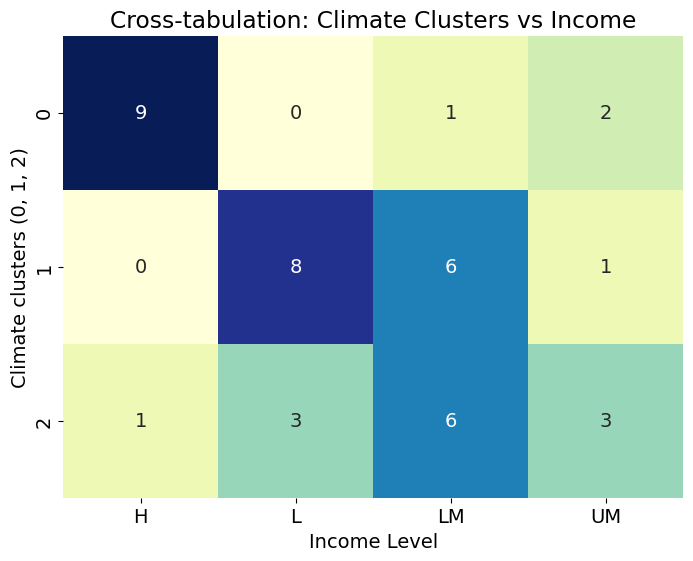

ARI: 0.247


In [67]:
ctab = pd.crosstab(country_profile['cluster_final'], country_profile['income_level_mode'])
plt.figure(figsize=(8, 6))
sns.heatmap(ctab, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title("Cross-tabulation: Climate Clusters vs Income")
plt.ylabel("Climate clusters (0, 1, 2)")
plt.xlabel("Income Level")
plt.show()
valid_mask = country_profile['income_level_mode'].notna()
ari_income = adjusted_rand_score(
    country_profile.loc[valid_mask, 'cluster_final'], 
    country_profile.loc[valid_mask, 'income_level_mode']
)
print(f"ARI: {ari_income:.3f}")

Clusters are not the same as income

Now let's see if there're countries with DALYs significantly higher or lower than expected given their climatic and economic profile. Case study: Ukraine

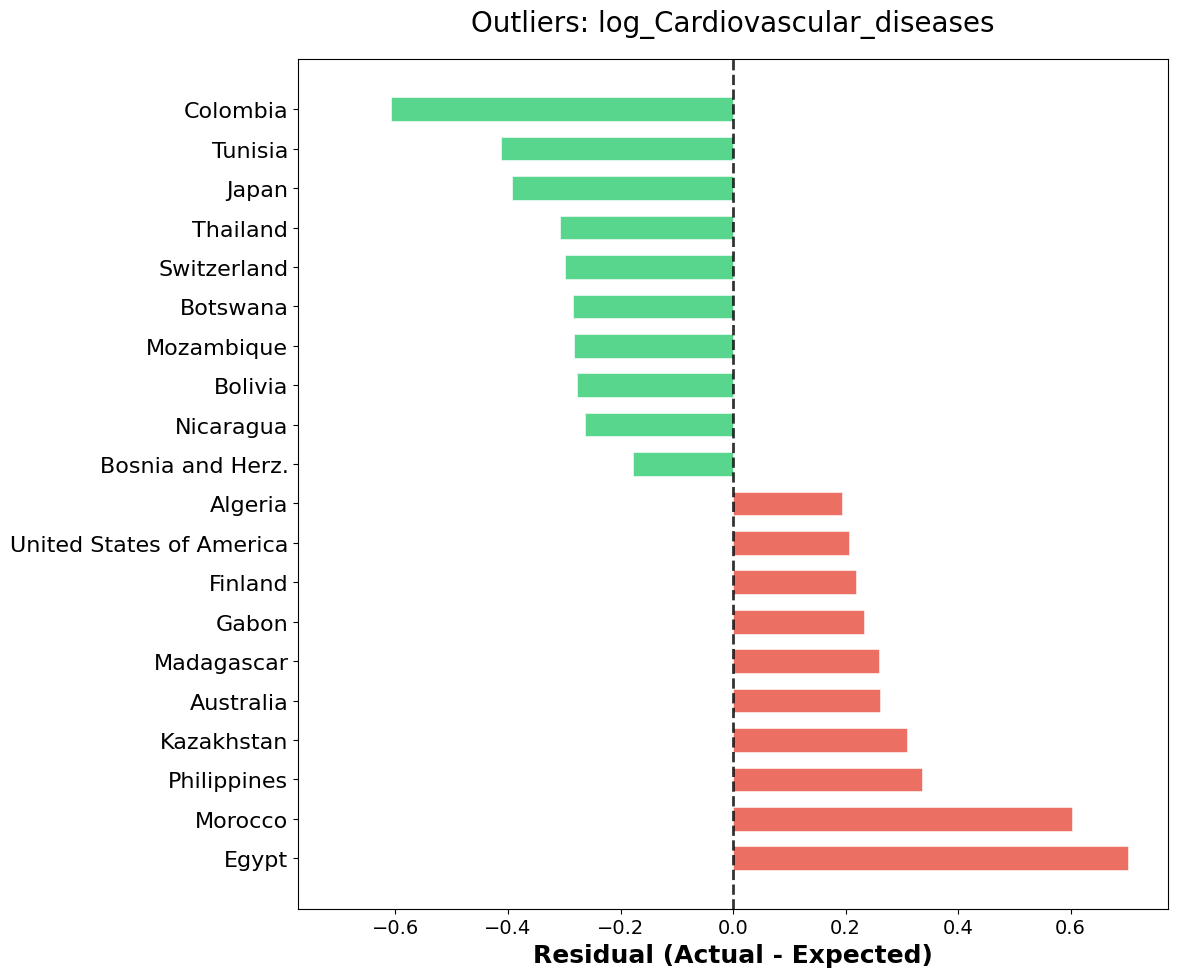


Case-study: Ukraine
Target Variable: log_Cardiovascular_diseases
Actual Value:    9.4285
Model Expected:  9.2988
Residual:        +0.1297
The burden of disease is higher than expected for Ukraine.


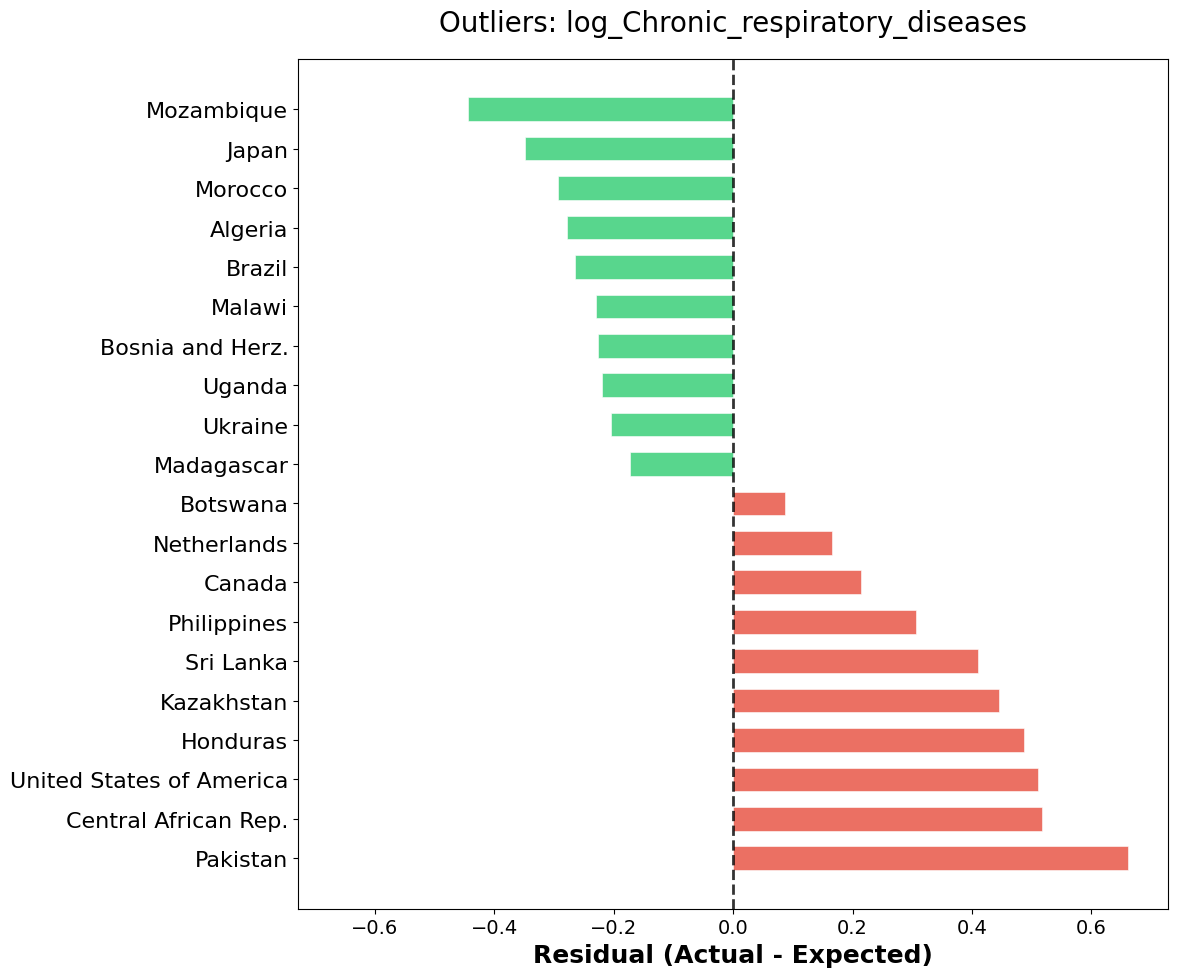


Case-study: Ukraine
Target Variable: log_Chronic_respiratory_diseases
Actual Value:    6.5828
Model Expected:  6.7872
Residual:        -0.2044
The burden of disease is lower than expected for Ukraine.


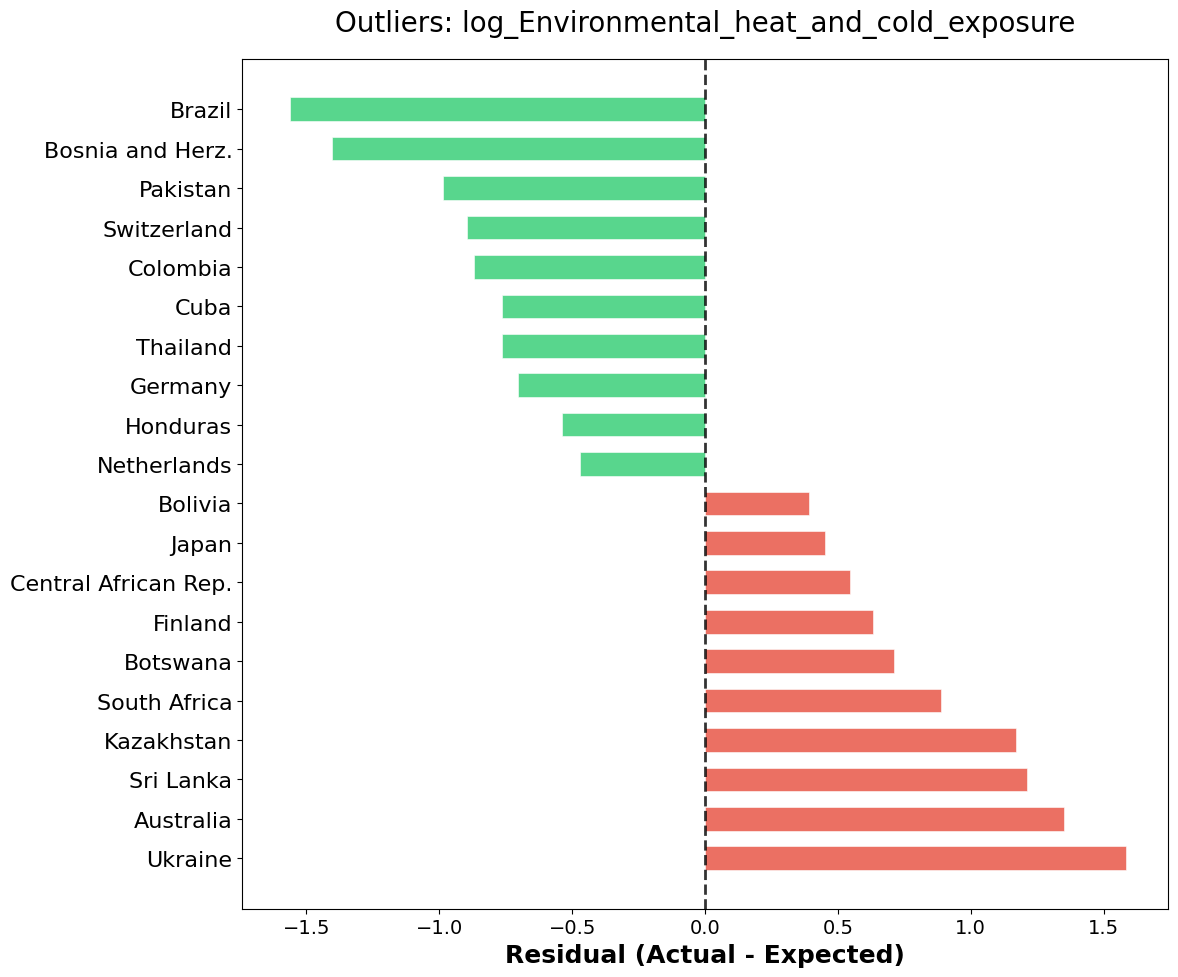


Case-study: Ukraine
Target Variable: log_Environmental_heat_and_cold_exposure
Actual Value:    5.5100
Model Expected:  3.9264
Residual:        +1.5837
The burden of disease is higher than expected for Ukraine.


In [63]:
def run_final_unique_analysis(df, target_col):
    group_col = 'country' if 'country' in df.columns else df.index
    
    df_grouped = df.groupby(group_col).agg({
        target_col: 'mean',
        'cluster_final': 'first',
        'income_level_mode': 'first'
    }).dropna()

    df_grouped['target'] = df_grouped[target_col]
    formula = 'target ~ C(cluster_final) + C(income_level_mode)'
    model = ols(formula, data=df_grouped).fit()

    df_grouped['expected'] = model.predict(df_grouped)
    df_grouped['residual'] = df_grouped['target'] - df_grouped['expected']
    
    return df_grouped.sort_values('residual', ascending=False)

def generate_country_report(results_df, target_name, country_query="Ukraine"):
    match = [idx for idx in results_df.index if country_query.lower() in str(idx).lower()]

    if match:
        name = match[0]
        row = results_df.loc[name]
        residual = float(row['residual'])
        status = "higher" if residual > 0 else "lower"
        
        print(f"\nCase-study: {name}")
        print(f"Target Variable: {target_name}")
        print(f"Actual Value:    {float(row['target']):.4f}")
        print(f"Model Expected:  {float(row['expected']):.4f}")
        print(f"Residual:        {residual:+.4f}")
        print(f"The burden of disease is {status} than expected for {country_query}.")
    else:
        print(f"\nNo data found for: '{country_query}' in {target_name} analysis.")

plt.rcParams.update({'font.size': 14})
country_to_analyze = "Ukraine"

for target in current_targets:
    final_results = run_final_unique_analysis(country_profile, target)
    plot_data = pd.concat([final_results.head(10), final_results.tail(10)])
    colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in plot_data['residual']]
    
    fig, ax = plt.subplots(figsize=(12, 10))
    y_pos = np.arange(len(plot_data))
    
    ax.barh(y_pos, plot_data['residual'].values, 
            height=0.6, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data.index, fontsize=16)
    ax.set_xlabel("Residual (Actual - Expected)", fontsize=18, fontweight='bold')
    ax.set_title(f"Outliers: {target}", fontsize=20, pad=20)
    
    ax.axvline(0, color='black', lw=2, ls='--', alpha=0.8)
    res_max = plot_data['residual'].abs().max() * 1.1
    ax.set_xlim(-res_max, res_max)
    
    plt.tight_layout()
    plt.savefig(clusters_plots_dir/f"{target}_res.pdf", bbox_inches='tight', dpi=300)
    plt.show()
    generate_country_report(final_results, target, country_query=country_to_analyze)

Let's see clusters on map.

In [68]:
iso_map = health_df[['country', 'iso3']].drop_duplicates().set_index('country')['iso3'].to_dict()
country_profile['iso3'] = country_profile['country'].map(iso_map)

cluster_names = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2"
}
country_profile['Cluster_Name'] = country_profile['cluster_final'].map(cluster_names)
fig = px.choropleth(
    country_profile,
    locations="iso3",
    color="Cluster_Name",
    hover_name="country",
    hover_data={
        "extreme_freq": ":.2f", 
        "pm25_mean": ":.1f",
        "seasonal_diff": ":.1f",
        "iso3": False,
        "Cluster_Name": False
    },
    title="Global Health-Centric Climate Clusters",
    color_discrete_map={
        cluster_names[0]: '#4575B4',
        cluster_names[1]: "#EE524A",
        cluster_names[2]: "#E79C55"
    },
)

fig.update_layout(
    geo=dict(
        showframe=False, 
        showcoastlines=True, 
        projection_type="natural earth",
        showland=True, landcolor="lightgray"
    ),
    margin=dict(l=0, r=0, t=50, b=0),
    legend=dict(
        title="Climate Profiles",
        yanchor="top", y=0.9, xanchor="left", x=0.02
    )
)
fig.write_image(clusters_plots_dir/"global_clusters_map.pdf", width=1000, height=600)
fig.show()